In [2]:
# ── 새 데이터로 v6r / v8r2 / v9r / v10 재학습 ────────────────────────────────
# 새 
# 기존 모델(sparsity_encoder_v6r.pth 등)을 덮어쓰지 않고 _new suffix로 별도 저장.
#
# ⚠ 순서 중요: v10은 v6r_new encoder를 frozen으로 재사용하므로
#   반드시 v6r_new를 먼저 학습 완료한 뒤 v10_new를 실행할 것.
#   v8r2_new / v9r_new는 v6r_new와 독립적이라 동시 실행 가능.

PY = '
BASE = '

steps = [
    ('1. v6r_new (먼저 실행)', f'{PY} {BASE}/train_v6r_new.py 2>&1 | tee train_v6r_new.log'),
    ('2a. v8r2_new (v6r_new와 무관, 동시 가능)', f'{PY} {BASE}/train_v8r2_new.py 2>&1 | tee train_v8r2_new.log'),
    ('2b. v9r_new (v6r_new와 무관, 동시 가능)', f'{PY} {BASE}/train_v9r_new.py 2>&1 | tee train_v9r_new.log'),
    ('3. v10_new (v6r_new 완료 후에만 실행)', f'{PY} {BASE}/train_v10_new.py 2>&1 | tee train_v10_new.log'),
]

print('tmux 창별로 아래 명령 실행:\n')
for label, cmd in steps:
    print(f'# {label}')
    print(cmd)
    print()

print('출력 파일:')
print('  sparsity_encoder_v6r_new.pth, v6r_embeddings_new.npy, v6r_images_new.npy')
print('  unet_gan_generator_v8r2_new.pth')
print('  unet_gan_generator_v9r_new.pth')
print('  v10_decoder_new.pth, train_v10_new_curves.pdf')


tmux 창별로 아래 명령 실행:

# 1. v6r_new (먼저 실행)


# 2a. v8r2_new (v6r_new와 무관, 동시 가능)


# 2b. v9r_new (v6r_new와 무관, 동시 가능)


# 3. v10_new (v6r_new 완료 후에만 실행)


출력 파일:
  sparsity_encoder_v6r_new.pth, v6r_embeddings_new.npy, v6r_images_new.npy
  unet_gan_generator_v8r2_new.pth
  unet_gan_generator_v9r_new.pth
  v10_decoder_new.pth, train_v10_new_curves.pdf


In [ ]:
# ── v6r_new Inference: 재학습된 retrieval 모델 평가 ──────────────────────────
# 독립 실행 가능
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class SparsityEncoder(nn.Module):
    def __init__(self, input_dim=196, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = SparsityEncoder().to(device)
encoder.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
encoder.eval()

embeddings_db = np.load('./v6r_embeddings_new.npy')
images_db     = np.load('./v6r_images_new.npy')

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))
print(f'Running v6r_new inference on {len(all_files)} files...', flush=True)

results = []   # (fname, label, true_idx, correct, ssim, gt, recon)
for fname in all_files:
    true_label = label_from_fname(fname)
    true_idx   = idx_from_fname(fname)
    if true_label is None or true_idx is None or true_idx >= len(images_db):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        vector = ast.literal_eval(fh.read().strip())
    if len(vector) != 196:
        continue
    sp_t = torch.tensor(vector, dtype=torch.float32).unsqueeze(0).to(device)
    gt   = images_db[true_idx]
    with torch.no_grad():
        q       = encoder(sp_t).cpu().numpy()
        ret_idx = int(np.argmax(embeddings_db @ q.T))
    recon   = images_db[ret_idx]
    ssim    = compute_ssim(gt, recon)
    correct = (ret_idx == true_idx)
    results.append((fname, true_label, true_idx, correct, ssim, gt, recon))

ssim_arr    = np.array([r[4] for r in results])
labels_arr  = np.array([r[1] for r in results])
correct_arr = np.array([r[3] for r in results])

print(f'\n{"="*55}')
print(f'  v6r_new 결과 ({len(results)} files)')
print(f'  Accuracy    : {correct_arr.sum()}/{len(results)} ({correct_arr.mean()*100:.1f}%)')
print(f'  Mean SSIM   : {ssim_arr.mean():.4f}')
print(f'  Median SSIM : {np.median(ssim_arr):.4f}')
print(f'{"="*55}')

print(f'\n  {"digit":>5}  {"n":>5}  {"acc%":>6}  {"mean SSIM":>10}  {"median":>8}')
print(f'  {"-"*5}  {"-"*5}  {"-"*6}  {"-"*10}  {"-"*8}')
for c in range(10):
    m = labels_arr == c
    if m.sum():
        print(f'  {c:>5}  {m.sum():>5}  {correct_arr[m].mean()*100:>5.1f}%  '
              f'{ssim_arr[m].mean():>10.4f}  {np.median(ssim_arr[m]):>8.4f}')

# ── 시각화: SSIM 분포 + per-class boxplot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ssim_arr, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(ssim_arr.mean(),     color='red',   linestyle='--', lw=1.2,
           label=f'Mean {ssim_arr.mean():.4f}')
ax.axvline(np.median(ssim_arr), color='black', linestyle=':',  lw=1.2,
           label=f'Median {np.median(ssim_arr):.4f}')
ax.set_xlabel('SSIM'); ax.set_ylabel('Count')
ax.set_title('v6r_new SSIM 분포')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
class_data = [ssim_arr[labels_arr == c] for c in range(10)]
ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
           medianprops=dict(color='red', linewidth=1.5),
           boxprops=dict(facecolor='steelblue', alpha=0.5),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_xlabel('Digit'); ax.set_ylabel('SSIM')
ax.set_title('v6r_new per-class SSIM')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('v6r_new_ssim.pdf', bbox_inches='tight')
fig.savefig('v6r_new_ssim.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: v6r_new_ssim.pdf, v6r_new_ssim.png')

In [ ]:
# ── v8r2_new Inference: 재학습된 class-conditional 모델 평가 ────────────────
# 독립 실행 가능  |  입력: sparsity + GT class label
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def sp_to_mask(sp):
    return F.interpolate(sp.view(-1, 1, 28, 7), size=(28, 28), mode='nearest')

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class DoubleConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )

class UNetGeneratorR(nn.Module):
    def __init__(self):
        super().__init__()
        self.class_embed = nn.Embedding(10, 28*28)
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.bot  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 256), nn.Dropout2d(0.2))
        self.up2  = nn.ConvTranspose2d(256, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)
        self.out  = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())
    def forward(self, sp, label):
        mask = sp_to_mask(sp)
        cls  = self.class_embed(label).view(-1, 1, 28, 28)
        x    = torch.cat([mask, cls], dim=1)
        e1 = self.enc1(x); e2 = self.enc2(e1); b = self.bot(e2)
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G8 = UNetGeneratorR().to(device)
G8.load_state_dict(torch.load('./unet_gan_generator_v8r2_new.pth', map_location=device))
G8.eval()

mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
images_db = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))
print(f'Running v8r2_new inference on {len(all_files)} files...', flush=True)

results = []   # (fname, label, true_idx, ssim, gt, recon)
for fname in all_files:
    true_label = label_from_fname(fname)
    true_idx   = idx_from_fname(fname)
    if true_label is None or true_idx is None or true_idx >= len(images_db):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        real_sp = ast.literal_eval(fh.read().strip())
    if len(real_sp) != 196:
        continue
    sp_t  = torch.tensor(real_sp, dtype=torch.float32).unsqueeze(0).to(device)
    lbl_t = torch.tensor([true_label], dtype=torch.long).to(device)
    gt    = images_db[true_idx]
    with torch.no_grad():
        recon = G8(sp_t, lbl_t).squeeze().cpu().numpy()
    ssim = compute_ssim(gt, recon)
    results.append((fname, true_label, true_idx, ssim, gt, recon))

ssim_arr   = np.array([r[3] for r in results])
labels_arr = np.array([r[1] for r in results])

print(f'\n{"="*55}')
print(f'  v8r2_new 결과 ({len(results)} files)')
print(f'  Mean SSIM   : {ssim_arr.mean():.4f}')
print(f'  Median SSIM : {np.median(ssim_arr):.4f}')
print(f'  SSIM > 0.85 : {(ssim_arr>0.85).sum()} ({(ssim_arr>0.85).mean()*100:.1f}%)')
print(f'  SSIM < 0.6  : {(ssim_arr<0.6).sum()} ({(ssim_arr<0.6).mean()*100:.1f}%)')
print(f'{"="*55}')

print(f'\n  {"digit":>5}  {"n":>5}  {"mean":>6}  {"median":>8}  {">0.85%":>8}  {"<0.6%":>7}')
print(f'  {"-"*5}  {"-"*5}  {"-"*6}  {"-"*8}  {"-"*8}  {"-"*7}')
for c in range(10):
    s = ssim_arr[labels_arr == c]
    if len(s):
        print(f'  {c:>5}  {len(s):>5}  {s.mean():>6.4f}  {np.median(s):>8.4f}  '
              f'{(s>0.85).mean()*100:>7.1f}%  {(s<0.6).mean()*100:>6.1f}%')

# ── 시각화: SSIM 분포 + per-class boxplot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ssim_arr, bins=50, color='seagreen', edgecolor='white', linewidth=0.3)
ax.axvline(ssim_arr.mean(),     color='red',   linestyle='--', lw=1.2,
           label=f'Mean {ssim_arr.mean():.4f}')
ax.axvline(np.median(ssim_arr), color='black', linestyle=':',  lw=1.2,
           label=f'Median {np.median(ssim_arr):.4f}')
ax.set_xlabel('SSIM'); ax.set_ylabel('Count')
ax.set_title('v8r2_new SSIM 분포')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
class_data = [ssim_arr[labels_arr == c] for c in range(10)]
ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
           medianprops=dict(color='red', linewidth=1.5),
           boxprops=dict(facecolor='seagreen', alpha=0.5),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_xlabel('Digit'); ax.set_ylabel('SSIM')
ax.set_title('v8r2_new per-class SSIM')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('v8r2_new_ssim.pdf', bbox_inches='tight')
fig.savefig('v8r2_new_ssim.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: v8r2_new_ssim.pdf, v8r2_new_ssim.png')

In [ ]:
# ── v9r_new Inference: 재학습된 sparsity-only 모델 평가 ─────────────────────
# 독립 실행 가능
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def sp_to_mask(sp):
    return F.interpolate(sp.view(-1, 1, 28, 7), size=(28, 28), mode='nearest')

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class DoubleConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )

class UNetGeneratorV9(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.bot  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.up2  = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)
        self.out  = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())
    def forward(self, sp):
        x  = sp_to_mask(sp)
        e1 = self.enc1(x); e2 = self.enc2(e1); b = self.bot(e2)
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G9 = UNetGeneratorV9().to(device)
G9.load_state_dict(torch.load('./unet_gan_generator_v9r_new.pth', map_location=device))
G9.eval()

mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
images_db = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))
print(f'Running v9r_new inference on {len(all_files)} files...', flush=True)

results = []   # (fname, label, true_idx, ssim, gt, recon)
for fname in all_files:
    true_label = label_from_fname(fname)
    true_idx   = idx_from_fname(fname)
    if true_label is None or true_idx is None or true_idx >= len(images_db):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        real_sp = ast.literal_eval(fh.read().strip())
    if len(real_sp) != 196:
        continue
    sp_t = torch.tensor(real_sp, dtype=torch.float32).unsqueeze(0).to(device)
    gt   = images_db[true_idx]
    with torch.no_grad():
        recon = G9(sp_t).squeeze().cpu().numpy()
    ssim = compute_ssim(gt, recon)
    results.append((fname, true_label, true_idx, ssim, gt, recon))

ssim_arr   = np.array([r[3] for r in results])
labels_arr = np.array([r[1] for r in results])

print(f'\n{"="*55}')
print(f'  v9r_new 결과 ({len(results)} files)')
print(f'  Mean SSIM   : {ssim_arr.mean():.4f}')
print(f'  Median SSIM : {np.median(ssim_arr):.4f}')
print(f'  SSIM > 0.85 : {(ssim_arr>0.85).sum()} ({(ssim_arr>0.85).mean()*100:.1f}%)')
print(f'  SSIM < 0.6  : {(ssim_arr<0.6).sum()} ({(ssim_arr<0.6).mean()*100:.1f}%)')
print(f'{"="*55}')

print(f'\n  {"digit":>5}  {"n":>5}  {"mean":>6}  {"median":>8}  {">0.85%":>8}  {"<0.6%":>7}')
print(f'  {"-"*5}  {"-"*5}  {"-"*6}  {"-"*8}  {"-"*8}  {"-"*7}')
for c in range(10):
    s = ssim_arr[labels_arr == c]
    if len(s):
        print(f'  {c:>5}  {len(s):>5}  {s.mean():>6.4f}  {np.median(s):>8.4f}  '
              f'{(s>0.85).mean()*100:>7.1f}%  {(s<0.6).mean()*100:>6.1f}%')

# ── 시각화: SSIM 분포 + per-class boxplot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ssim_arr, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax.axvline(ssim_arr.mean(),     color='red',   linestyle='--', lw=1.2,
           label=f'Mean {ssim_arr.mean():.4f}')
ax.axvline(np.median(ssim_arr), color='black', linestyle=':',  lw=1.2,
           label=f'Median {np.median(ssim_arr):.4f}')
ax.set_xlabel('SSIM'); ax.set_ylabel('Count')
ax.set_title('v9r_new SSIM 분포')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
class_data = [ssim_arr[labels_arr == c] for c in range(10)]
ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
           medianprops=dict(color='red', linewidth=1.5),
           boxprops=dict(facecolor='coral', alpha=0.5),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_xlabel('Digit'); ax.set_ylabel('SSIM')
ax.set_title('v9r_new per-class SSIM')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('v9r_new_ssim.pdf', bbox_inches='tight')
fig.savefig('v9r_new_ssim.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: v9r_new_ssim.pdf, v9r_new_ssim.png')

In [ ]:
# ── v10_new Inference: 재학습된 v6r_new encoder + V10Decoder 평가 ───────────
# 독립 실행 가능
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class SparsityEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(196, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, 128),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class V10Decoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 7, 7)
        return self.net(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

enc = SparsityEncoder().to(device)
enc.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
enc.eval()
for p in enc.parameters(): p.requires_grad_(False)

Dec = V10Decoder().to(device)
Dec.load_state_dict(torch.load('./v10_decoder_new.pth', map_location=device))
Dec.eval()

mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
images_db = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))
print(f'Running v10_new inference on {len(all_files)} files...', flush=True)

results = []   # (fname, label, true_idx, ssim, gt, recon)
for fname in all_files:
    true_label = label_from_fname(fname)
    true_idx   = idx_from_fname(fname)
    if true_label is None or true_idx is None or true_idx >= len(images_db):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        real_sp = ast.literal_eval(fh.read().strip())
    if len(real_sp) != 196:
        continue
    sp_t = torch.tensor(real_sp, dtype=torch.float32).unsqueeze(0).to(device)
    gt   = images_db[true_idx]
    with torch.no_grad():
        z     = enc(sp_t)
        recon = Dec(z).squeeze().cpu().numpy()
    ssim = compute_ssim(gt, recon)
    results.append((fname, true_label, true_idx, ssim, gt, recon))

ssim_arr   = np.array([r[3] for r in results])
labels_arr = np.array([r[1] for r in results])

print(f'\n{"="*55}')
print(f'  v10_new 결과 ({len(results)} files)')
print(f'  Mean SSIM  : {ssim_arr.mean():.4f}')
print(f'  Median SSIM: {np.median(ssim_arr):.4f}')
print(f'  SSIM < 0.6 : {(ssim_arr<0.6).sum()} ({(ssim_arr<0.6).mean()*100:.1f}%)')
print(f'  SSIM > 0.85: {(ssim_arr>0.85).sum()} ({(ssim_arr>0.85).mean()*100:.1f}%)')
print(f'{"="*55}')

print(f'\n  {"digit":>5}  {"n":>5}  {"mean":>6}  {"median":>8}  {"<0.6":>8}')
print(f'  {"-"*5}  {"-"*5}  {"-"*6}  {"-"*8}  {"-"*8}')
for c in range(10):
    s = ssim_arr[labels_arr == c]
    if len(s):
        print(f'  {c:>5}  {len(s):>5}  {s.mean():>6.4f}  '
              f'{np.median(s):>8.4f}  {(s<0.6).sum():>4} ({(s<0.6).mean()*100:.0f}%)')

# ── 시각화: SSIM 분포 + per-class boxplot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ssim_arr, bins=50, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.axvline(ssim_arr.mean(),       color='red',   linestyle='--', lw=1.2,
           label=f'Mean {ssim_arr.mean():.4f}')
ax.axvline(np.median(ssim_arr),   color='black', linestyle=':',  lw=1.2,
           label=f'Median {np.median(ssim_arr):.4f}')
ax.set_xlabel('SSIM'); ax.set_ylabel('Count')
ax.set_title('v10_new SSIM 분포')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
class_data = [ssim_arr[labels_arr == c] for c in range(10)]
ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
           medianprops=dict(color='red', linewidth=1.5),
           boxprops=dict(facecolor='mediumpurple', alpha=0.5),
           flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_xlabel('Digit'); ax.set_ylabel('SSIM')
ax.set_title('v10_new per-class SSIM')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('v10_new_ssim.pdf', bbox_inches='tight')
fig.savefig('v10_new_ssim.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: v10_new_ssim.pdf, v10_new_ssim.png')

In [7]:
# ── 3개 모델 비교: 추론 ──────────────────────────────────────────────────────
# 독립 실행 가능  |  v8r2 / v9r / v10 추론만 수행, 그래프는 다음 셀
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def sp_to_mask(sp):
    return F.interpolate(sp.view(-1, 1, 28, 7), size=(28, 28), mode='nearest')

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class SparsityEncoder(nn.Module):
    def __init__(self, input_dim=196, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class DoubleConv(nn.Sequential):
    def __init__(self, cin, cout):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )

class UNetGeneratorR(nn.Module):
    def __init__(self):
        super().__init__()
        self.class_embed = nn.Embedding(10, 28*28)
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.bot  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 256), nn.Dropout2d(0.2))
        self.up2  = nn.ConvTranspose2d(256, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)
        self.out  = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())
    def forward(self, sp, label):
        mask = sp_to_mask(sp)
        cls  = self.class_embed(label).view(-1, 1, 28, 28)
        x    = torch.cat([mask, cls], dim=1)
        e1 = self.enc1(x); e2 = self.enc2(e1); b = self.bot(e2)
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1).squeeze(1)

class UNetGeneratorV9(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.bot  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.up2  = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)
        self.out  = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())
    def forward(self, sp):
        x  = sp_to_mask(sp)
        e1 = self.enc1(x); e2 = self.enc2(e1); b = self.bot(e2)
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1).squeeze(1)

class V10Decoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 7, 7)
        return self.net(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
mnist_img = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))

test_items = []
for fname in all_files:
    true_label = label_from_fname(fname)
    true_idx   = idx_from_fname(fname)
    if true_label is None or true_idx is None or true_idx >= len(mnist_img):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        sp = ast.literal_eval(fh.read().strip())
    if len(sp) != 196:
        continue
    test_items.append((sp, true_label, true_idx))

print(f'테스트 샘플: {len(test_items)}개', flush=True)

G8 = UNetGeneratorR().to(device)
G8.load_state_dict(torch.load('./unet_gan_generator_v8r2_new.pth', map_location=device))
G8.eval()

v8r2_ssim, v8r2_labels = [], []
with torch.no_grad():
    for sp, lbl, idx in test_items:
        sp_t  = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        lbl_t = torch.tensor([lbl], dtype=torch.long).to(device)
        recon = G8(sp_t, lbl_t).squeeze().cpu().numpy()
        v8r2_ssim.append(compute_ssim(mnist_img[idx], recon))
        v8r2_labels.append(lbl)
v8r2_ssim, v8r2_labels = np.array(v8r2_ssim), np.array(v8r2_labels)
print(f'v8r2_new done  Mean={v8r2_ssim.mean():.4f}', flush=True)

G9 = UNetGeneratorV9().to(device)
G9.load_state_dict(torch.load('./unet_gan_generator_v9r_new.pth', map_location=device))
G9.eval()

v9r_ssim, v9r_labels = [], []
with torch.no_grad():
    for sp, lbl, idx in test_items:
        sp_t  = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        recon = G9(sp_t).squeeze().cpu().numpy()
        v9r_ssim.append(compute_ssim(mnist_img[idx], recon))
        v9r_labels.append(lbl)
v9r_ssim, v9r_labels = np.array(v9r_ssim), np.array(v9r_labels)
print(f'v9r_new  done  Mean={v9r_ssim.mean():.4f}', flush=True)

v10_enc = SparsityEncoder().to(device)
v10_enc.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
v10_enc.eval()
v10_dec = V10Decoder().to(device)
v10_dec.load_state_dict(torch.load('./v10_decoder_new.pth', map_location=device))
v10_dec.eval()

v10_ssim, v10_labels = [], []
with torch.no_grad():
    for sp, lbl, idx in test_items:
        sp_t  = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        recon = v10_dec(v10_enc(sp_t)).squeeze().cpu().numpy()
        v10_ssim.append(compute_ssim(mnist_img[idx], recon))
        v10_labels.append(lbl)
v10_ssim, v10_labels = np.array(v10_ssim), np.array(v10_labels)
print(f'v10_new  done  Mean={v10_ssim.mean():.4f}', flush=True)
print('추론 완료. 다음 셀에서 그래프 생성.')

100%|██████████| 9.91M/9.91M [00:00<00:00, 71.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 5.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 26.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.90MB/s]


테스트 샘플: 2501개
v8r2_new done  Mean=0.9337
v9r_new  done  Mean=0.6817
v10_new  done  Mean=0.9067
추론 완료. 다음 셀에서 그래프 생성.


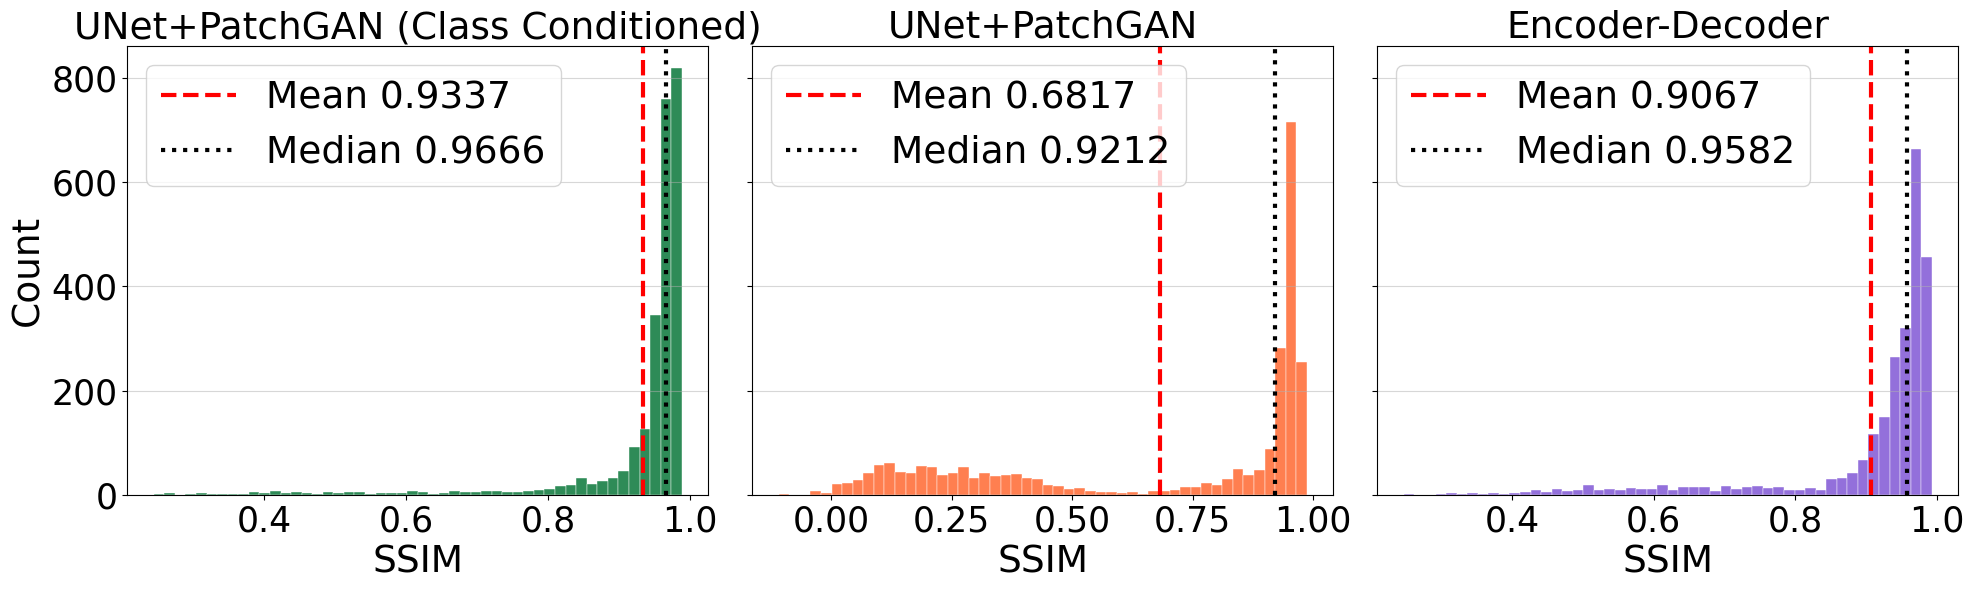

/tmp/ipykernel_466589/3497658165.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
/tmp/ipykernel_466589/3497658165.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
/tmp/ipykernel_466589/3497658165.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,


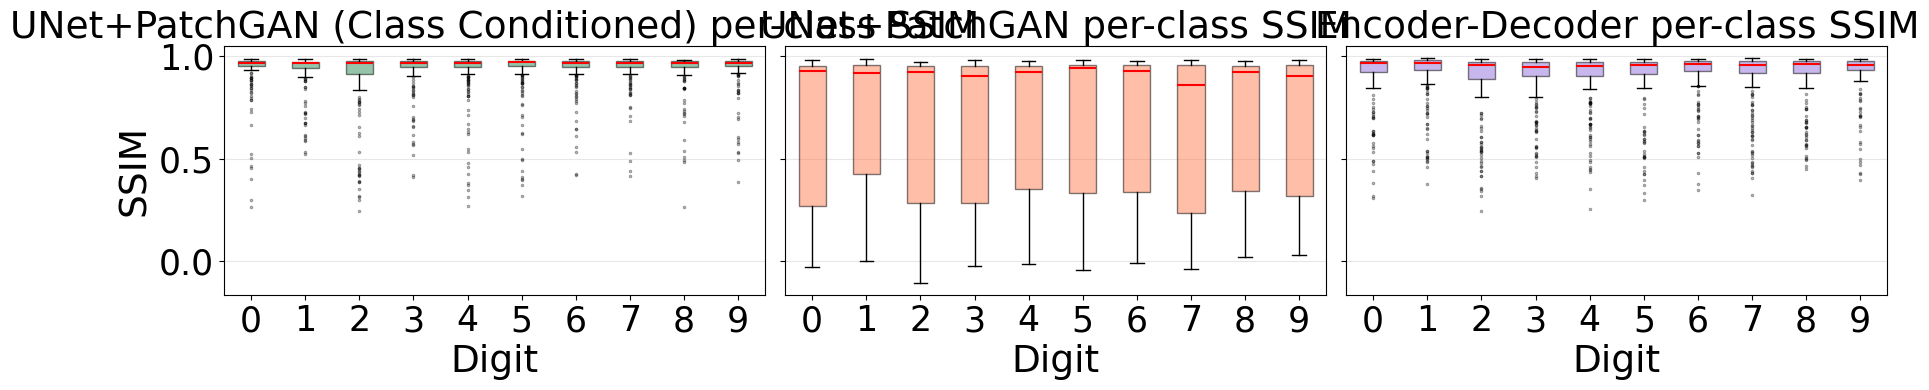

Saved: comparison_hist.pdf/png, comparison_boxplot.pdf/png


In [2]:
# ── 3개 모델 비교: 그래프 (추론 셀 먼저 실행) ────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

FS = 27

models = [
    ('UNet+PatchGAN (Class Conditioned)', v8r2_ssim, v8r2_labels, 'seagreen'),
    ('UNet+PatchGAN',  v9r_ssim,  v9r_labels,  'coral'),
    ('Encoder-Decoder',  v10_ssim,  v10_labels,  'mediumpurple'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, (name, sarr, larr, clr) in zip(axes, models):
    ax.hist(sarr, bins=50, color=clr, edgecolor='white', linewidth=0.3)
    ax.axvline(sarr.mean(),     color='red',   linestyle='--', lw=3,
               label=f'Mean {sarr.mean():.4f}')
    ax.axvline(np.median(sarr), color='black', linestyle=':',  lw=3,
               label=f'Median {np.median(sarr):.4f}')
    ax.set_xlabel('SSIM', fontsize=FS)
    ax.set_title(name, fontsize=FS)
    ax.legend(fontsize=FS); ax.grid(True, alpha=0.5, axis='y')
    ax.tick_params(labelsize=FS-2)
axes[0].set_ylabel('Count', fontsize=FS)
plt.tight_layout()
fig.savefig('comparison_hist.pdf', bbox_inches='tight')
fig.savefig('comparison_hist.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (name, sarr, larr, clr) in zip(axes, models):
    class_data = [sarr[larr == c] for c in range(10)]
    ax.boxplot(class_data, labels=list(range(10)), patch_artist=True,
               medianprops=dict(color='red', linewidth=1.5),
               boxprops=dict(facecolor=clr, alpha=0.5),
               flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_xlabel('Digit', fontsize=FS)
    ax.set_title(f'{name} per-class SSIM', fontsize=FS)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(labelsize=FS-2)
axes[0].set_ylabel('SSIM', fontsize=FS)
plt.tight_layout()
fig.savefig('comparison_boxplot.pdf', bbox_inches='tight')
fig.savefig('comparison_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: comparison_hist.pdf/png, comparison_boxplot.pdf/png')

## This

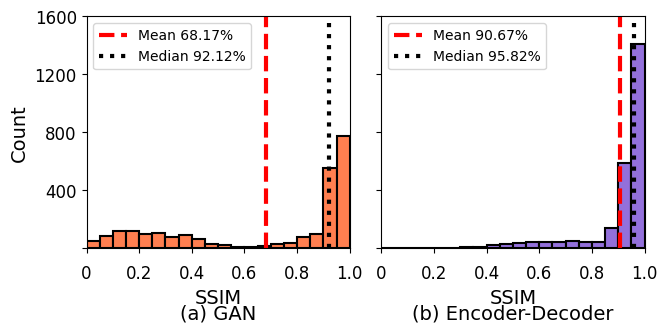

In [7]:
import matplotlib.pyplot as plt
import numpy as np

FS = 14

models = [
    # ('Label-Guided GAN', v8r2_ssim, v8r2_labels, 'seagreen'),
     ('GAN', v9r_ssim, v9r_labels, 'coral'),
    ('Encoder-Decoder', v10_ssim, v10_labels, 'mediumpurple'),
]

# 모든 모델에서 동일한 x축 범위
XMIN = 0.0
XMAX = 1.0
XTICKS = np.arange(0.0, 1.01, 0.2)

fig, axes = plt.subplots(1, 2, figsize=(6, 1.6), sharey=True)
from matplotlib.ticker import FuncFormatter

for ax in axes:
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, pos: '' if y == 0 else f'{y:.0f}')
    )
for i, (ax, (name, sarr, larr, clr)) in enumerate(zip(axes, models)):
    ax.hist(
        sarr,
        bins=20,
        range=(XMIN, XMAX),
        color=clr,
        edgecolor='black',
        linewidth=1.5
    )

    # Mean / Median: percentage
    ax.axvline(
        sarr.mean(),
        color='red',
        linestyle='--',
        lw=3,
        label=f'Mean {sarr.mean() * 100:.2f}%'
    )

    ax.axvline(
        np.median(sarr),
        color='black',
        linestyle=':',
        lw=3,
        label=f'Median {np.median(sarr) * 100:.2f}%'
    )

    # 동일한 x축
    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(XTICKS)
    ax.set_xticklabels([
        '0' if x == 0 else f'{x:.1f}'
        for x in XTICKS
    ])

    ax.set_xlabel('SSIM', fontsize=FS)

    ax.legend(fontsize=FS-4)
    # ax.grid(True, alpha=1.0, axis='y')
    ax.tick_params(labelsize=FS-2)

    # SSIM 바로 아래에 (a), (b), (c)
    ax.text(
        0.5, -0.24,
        f'({chr(97+i)}) {name}',
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=FS
    )

axes[0].set_ylabel('Count', fontsize=FS)
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=-0.5,
    top=0.95,
    wspace=0.12
)
plt.yticks([0,400, 800, 1200,1600])

# subplot 사이의 tick label이 겹치지 않도록
for ax in axes:
    ax.tick_params(axis='x', pad=8)
# for ax in axes:
#     ax.tick_params(axis='y', pad=8)
fig.savefig('comparison_hist.pdf', bbox_inches='tight')
fig.savefig('comparison_hist.png', bbox_inches='tight', dpi=150)

plt.show()

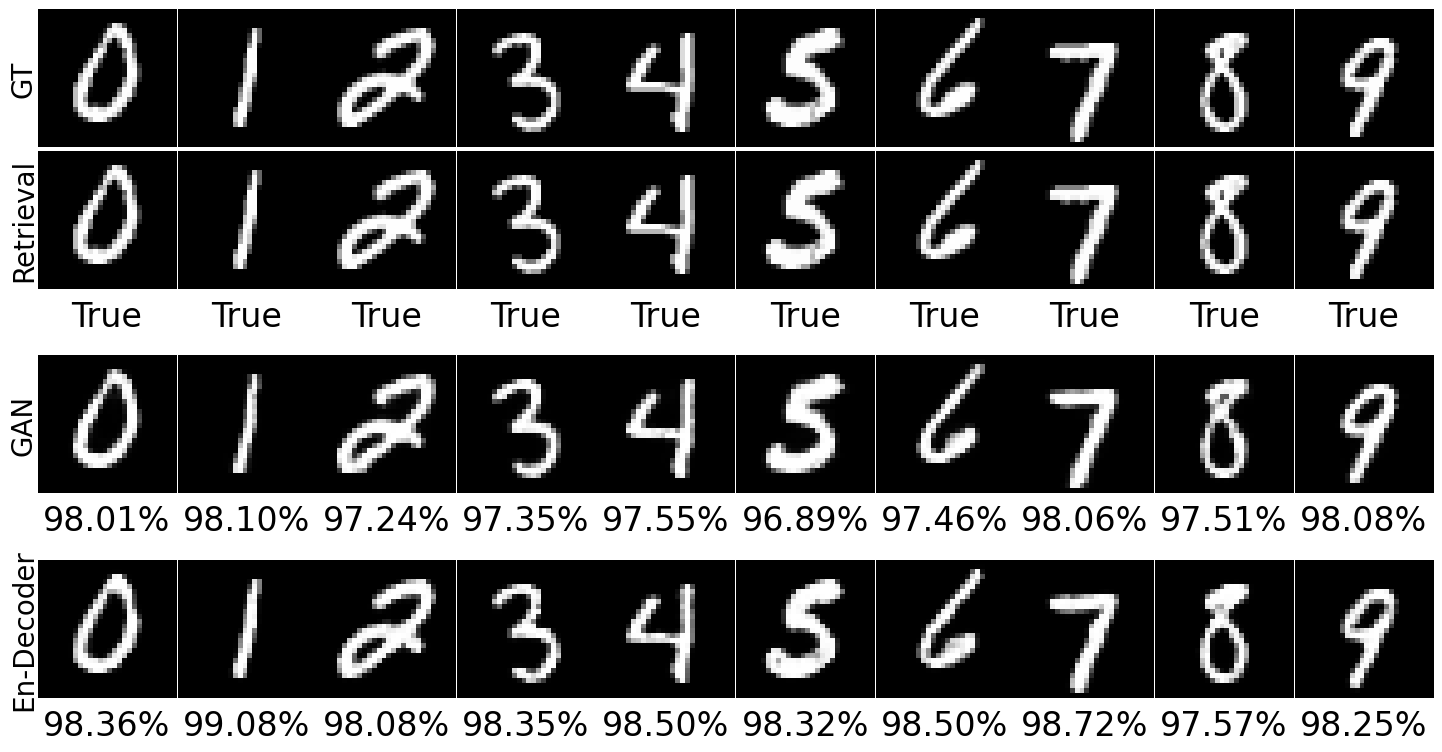

Saved: v6r_v9r_v10_best_samples.pdf/png


In [39]:
# ── v6r / v9r / v10 Best Sample per Digit (4x10, balanced best) ─────────────
import matplotlib.pyplot as plt
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from scipy.ndimage import uniform_filter

device = torch.device('cpu')

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

class _V6Enc(nn.Module):
    def __init__(self, input_dim=196, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

_v6enc = _V6Enc().to(device)
_v6enc.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
_v6enc.eval()
_emb_db = np.load('./v6r_embeddings_new.npy')
_img_db = np.load('./v6r_images_new.npy')

v6r_ssim, v6r_recon = [], []
with torch.no_grad():
    for sp, lbl, idx in test_items:
        sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        q    = _v6enc(sp_t).cpu().numpy()
        ret  = int(np.argmax(_emb_db @ q.T))
        v6r_recon.append(_img_db[ret])
        v6r_ssim.append(compute_ssim(mnist_img[idx], _img_db[ret]))
v6r_ssim  = np.array(v6r_ssim)
v6r_recon = np.stack(v6r_recon)

balance_score = (v6r_ssim + v9r_ssim + v10_ssim) / 3.0

FS = 30
row_names = ['GT', 'Retrieval', 'GAN', 'En-Decoder']

fig, axes = plt.subplots(4, 10, figsize=(18, 10.5))
fig.subplots_adjust(wspace=0.01, hspace=0.05)

for digit in range(10):
    mask = np.where(v10_labels == digit)[0]
    best = mask[balance_score[mask].argmax()]

    sp, lbl, img_idx = test_items[best]
    gt = mnist_img[img_idx]

    sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        recon9  = G9(sp_t).squeeze().cpu().numpy()
        recon10 = v10_dec(v10_enc(sp_t)).squeeze().cpu().numpy()
    recon6  = v6r_recon[best]
    v6r_txt = 'True' if v6r_ssim[best] >= 0.9999 else f'{v6r_ssim[best]*100:.2f}%'

    imgs  = [gt, recon6, recon9, recon10]
    ssims = [None, v6r_txt, f'{v9r_ssim[best]*100:.2f}%', f'{v10_ssim[best]*100:.2f}%']

    for row, (im, sv) in enumerate(zip(imgs, ssims)):
        ax = axes[row, digit]
        ax.imshow(im, cmap='gray', vmin=0, vmax=1, aspect='equal')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_visible(False)
        if sv is not None:
            ax.text(0.5, -0.08, sv, fontsize=FS-6,
                    ha='center', va='top', transform=ax.transAxes)

for row, name in enumerate(row_names):
    axes[row, 0].set_ylabel(name, fontsize=FS-10, rotation=90, labelpad=10, va='center')

# GT row 아래로 shift
for ax in axes[0, :]:
    bb = ax.get_position()
    ax.set_position([bb.x0, bb.y0 - 0.06, bb.width, bb.height])

fig.savefig('v6r_v9r_v10_best_samples.pdf', bbox_inches='tight')
fig.savefig('v6r_v9r_v10_best_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: v6r_v9r_v10_best_samples.pdf/png')


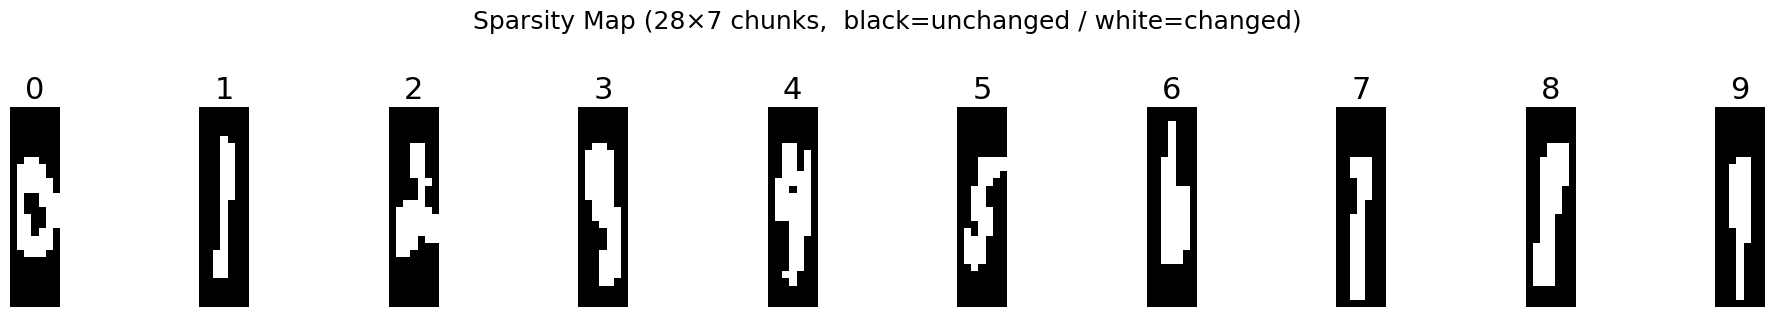

In [15]:
# ── v10 Best Sample per Digit — Sparsity Map 시각화 ──────────────────────────
# 선행: c76e3060 셀 (v10_ssim, v10_labels, test_items 필요)
import matplotlib.pyplot as plt
import numpy as np

FS = 22

fig, axes = plt.subplots(1, 10, figsize=(20, 3))
fig.subplots_adjust(wspace=0.05)

for digit in range(10):
    mask = np.where(v10_labels == digit)[0]
    best = mask[v10_ssim[mask].argmax()]

    item = test_items[best]
    sp = item[0]  # 196-element list

    # 196 chunks = 28행 × 7열 (chunk 하나 = 가로 4픽셀)
    sp_arr = np.array(sp, dtype=np.float32).reshape(28, 7)

    ax = axes[digit]
    ax.imshow(sp_arr, cmap='binary_r', vmin=0, vmax=1,
              aspect='equal', interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(str(digit), fontsize=FS)

fig.suptitle('Sparsity Map (28×7 chunks,  black=unchanged / white=changed)', fontsize=FS - 4, y=1.04)
plt.tight_layout()
plt.show()


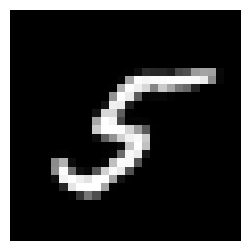

Saved: recovered_best_label5.pdf


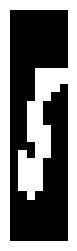

Saved: sparsitymap_best_label5.pdf


In [13]:
# ── v10 Best Sample (label=5): recovered + sparsitymap PDF 저장 ──────────────
# 선행: b5fe9012 셀 (v10_ssim, v10_labels, test_items, v10_enc, v10_dec, mnist_img)
import matplotlib.pyplot as plt
import numpy as np, torch

TARGET_LABEL = 5
mask = np.where(v10_labels == TARGET_LABEL)[0]
best = mask[v10_ssim[mask].argmax()]

sp, lbl, img_idx = test_items[best]
sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    recon = v10_dec(v10_enc(sp_t)).squeeze().cpu().numpy()

gt = mnist_img[img_idx]
ssim_val = v10_ssim[best]

# ── 1. recovered_best_label5.pdf ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(recon, cmap='gray', vmin=0, vmax=1, aspect='equal')
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values(): spine.set_visible(False)
#ax.set_title(f'label={lbl}  SSIM={ssim_val*100:.2f}%', fontsize=14)
fig.savefig('recovered_best_label5.png', bbox_inches='tight')
plt.show()
print('Saved: recovered_best_label5.pdf')

# ── 2. sparsitymap_best_label5.pdf ───────────────────────────────────────────
sp_arr = np.array(sp, dtype=np.float32).reshape(28, 7)

fig, ax = plt.subplots(figsize=(2, 3))
ax.imshow(sp_arr, cmap='binary_r', vmin=0, vmax=1,
          aspect='equal', interpolation='nearest')
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values(): spine.set_visible(False)
#ax.set_title(f'label={lbl}', fontsize=14)
fig.savefig('sparsitymap_best_label5.png', bbox_inches='tight')
plt.show()
print('Saved: sparsitymap_best_label5.pdf')


In [ ]:
# ── v10 Split Ratio Inference (9:1 / 8:2 / 7:3 / 6:4) ─────────────────────
# 독립 실행 가능  |  encoder: sparsity_encoder_v6r_new.pth (split 모델도 new encoder로 학습됨)
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

class SparsityEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(196, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, 128),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class V10Decoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 7, 7)
        return self.net(x).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

enc = SparsityEncoder().to(device)
enc.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
enc.eval()
for p in enc.parameters(): p.requires_grad_(False)

mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
images_db = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

OUT_LIST_DIR = '
all_files    = sorted(f for f in os.listdir(OUT_LIST_DIR) if f.endswith('.out_v5.list'))

test_items = []
for fname in all_files:
    true_idx = idx_from_fname(fname)
    if true_idx is None or true_idx >= len(images_db):
        continue
    with open(os.path.join(OUT_LIST_DIR, fname)) as fh:
        sp = ast.literal_eval(fh.read().strip())
    if len(sp) != 196:
        continue
    test_items.append((sp, images_db[true_idx]))

splits = [
    ('9:1', './v10_decoder_new.pth'),
    ('8:2', './v10_decoder_split80.pth'),
    ('7:3', './v10_decoder_split70.pth'),
    ('6:4', './v10_decoder_split60.pth'),
]

rows = []
for label, ckpt in splits:
    Dec = V10Decoder().to(device)
    Dec.load_state_dict(torch.load(ckpt, map_location=device))
    Dec.eval()
    ssims = []
    with torch.no_grad():
        for sp, gt in test_items:
            sp_t  = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
            recon = Dec(enc(sp_t)).squeeze().cpu().numpy()
            ssims.append(compute_ssim(gt, recon))
    arr = np.array(ssims)
    n     = len(arr)
    mean  = arr.mean()
    med   = np.median(arr)
    lt08  = int((arr < 0.8).sum())
    lt08p = lt08 / n * 100
    rows.append((label, n, mean, med, lt08, lt08p))
    print(f'[{label} split]  n={n}  Mean={mean:.4f}  Median={med:.4f}  '
          f'SSIM<0.8: {lt08} ({lt08p:.1f}%)')

print(f'\n {"split":>5}  {"n":>6}  {"mean":>8}  {"median":>8}  {"<0.8 cnt":>9}  {"<0.8 %":>7}')
print(f' {"-"*5}  {"-"*6}  {"-"*8} 지금 호스트 커너 {"-"*8}  {"-"*9}  {"-"*7}')
for label, n, mean, med, lt08, lt08p in rows:
    print(f' {label:>5}  {n:>6}  {mean:>8.4f}  {med:>8.4f}  {lt08:>9}  {lt08p:>6.1f}%')

[9:1 split]  n=2501  Mean=0.9067  Median=0.9582  SSIM<0.8: 327 (13.1%)
[8:2 split]  n=2501  Mean=0.8843  Median=0.9609  SSIM<0.8: 530 (21.2%)
[7:3 split]  n=2501  Mean=0.8499  Median=0.9467  SSIM<0.8: 751 (30.0%)
[6:4 split]  n=2501  Mean=0.8215  Median=0.9409  SSIM<0.8: 980 (39.2%)

 split       n      mean    median   <0.8 cnt   <0.8 %
 -----  ------  --------  --------  ---------  -------
   9:1    2501    0.9067    0.9582        327    13.1%
   8:2    2501    0.8843    0.9609        530    21.2%
   7:3    2501    0.8499    0.9467        751    30.0%
   6:4    2501    0.8215    0.9409        980    39.2%


In [2]:
# ── Misalignment Sensitivity: offset error → SSIM (계산) ─────────────────────
# 독립 실행 가능 | 그래프는 다음 셀
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, ast, re, json
from torchvision import datasets, transforms
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

def idx_from_fname(fname):
    m = re.search(r'-(\d+)\.out_v5\.list$', fname); return int(m.group(1)) if m else None

def label_from_fname(fname):
    m = re.match(r'^(\d+)-', fname); return int(m.group(1)) if m else None

class SparsityEncoder(nn.Module):
    def __init__(self, input_dim=196, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class V10Decoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        x = F.relu(self.fc(z)).view(-1, 256, 7, 7)
        return self.net(x).squeeze(1)

def shift_sparsity(vec, delta_chunks):
    shifted = [0] * 196
    for i in range(196):
        src = i + delta_chunks
        if 0 <= src < 196:
            shifted[i] = vec[src]
    return shifted

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = SparsityEncoder().to(device)
encoder.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
encoder.eval()
for p in encoder.parameters(): p.requires_grad_(False)

dec = V10Decoder().to(device)
dec.load_state_dict(torch.load('./v10_decoder_new.pth', map_location=device))
dec.eval()

mnist     = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
mnist_img = np.stack([mnist[i][0].squeeze().numpy() for i in range(len(mnist))])

with open('
    json_data = json.load(f)
gt_sp = {item['sample_idx']: item['input_sparsity_seq'] for item in json_data}

OUT_DIR = '
test_samples = []
for fname in sorted(os.listdir(OUT_DIR)):
    if not fname.endswith('.out_v5.list'):
        continue
    idx, lbl = idx_from_fname(fname), label_from_fname(fname)
    if idx is not None and lbl is not None and idx in gt_sp:
        test_samples.append((idx, lbl))
print(f'Test samples: {len(test_samples)}', flush=True)

DELTAS_BYTES = [0, 64, 128, 256, 512, 768, 960, 1280, 1664, 2336, 3136, 3520, 3904, 4480]
CHUNK_SIZE   = 16

ms_results = {}
for db in DELTAS_BYTES:
    dc = db // CHUNK_SIZE
    ssims = []
    for idx, true_lbl in test_samples:
        sp = shift_sparsity(gt_sp[idx], dc)
        sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            recon = dec(encoder(sp_t)).squeeze().cpu().numpy()
        ssims.append(compute_ssim(mnist_img[idx], recon))
    ms_results[db] = {'mean_ssim': np.mean(ssims), 'std_ssim': np.std(ssims)}
    print(f'  delta={db:+5d}B ({dc:+3d} chunks)  '
          f'SSIM={ms_results[db]["mean_ssim"]:.4f} ± {ms_results[db]["std_ssim"]:.4f}')

print('\n계산 완료. 다음 셀에서 그래프 생성.')

Test samples: 2501
  delta=   +0B ( +0 chunks)  SSIM=0.9339 ± 0.1069
  delta=  +64B ( +4 chunks)  SSIM=0.4223 ± 0.0964
  delta= +128B ( +8 chunks)  SSIM=0.4133 ± 0.0873
  delta= +256B (+16 chunks)  SSIM=0.3960 ± 0.0735
  delta= +512B (+32 chunks)  SSIM=0.4082 ± 0.0950
  delta= +768B (+48 chunks)  SSIM=0.4308 ± 0.0934
  delta= +960B (+60 chunks)  SSIM=0.4222 ± 0.0864
  delta=+1280B (+80 chunks)  SSIM=0.4360 ± 0.0925
  delta=+1664B (+104 chunks)  SSIM=0.4326 ± 0.0970
  delta=+2336B (+146 chunks)  SSIM=0.4569 ± 0.1068
  delta=+3136B (+196 chunks)  SSIM=0.4619 ± 0.1185
  delta=+3520B (+220 chunks)  SSIM=0.4619 ± 0.1185
  delta=+3904B (+244 chunks)  SSIM=0.4619 ± 0.1185
  delta=+4480B (+280 chunks)  SSIM=0.4619 ± 0.1185

계산 완료. 다음 셀에서 그래프 생성.


Misaligned samples: 982


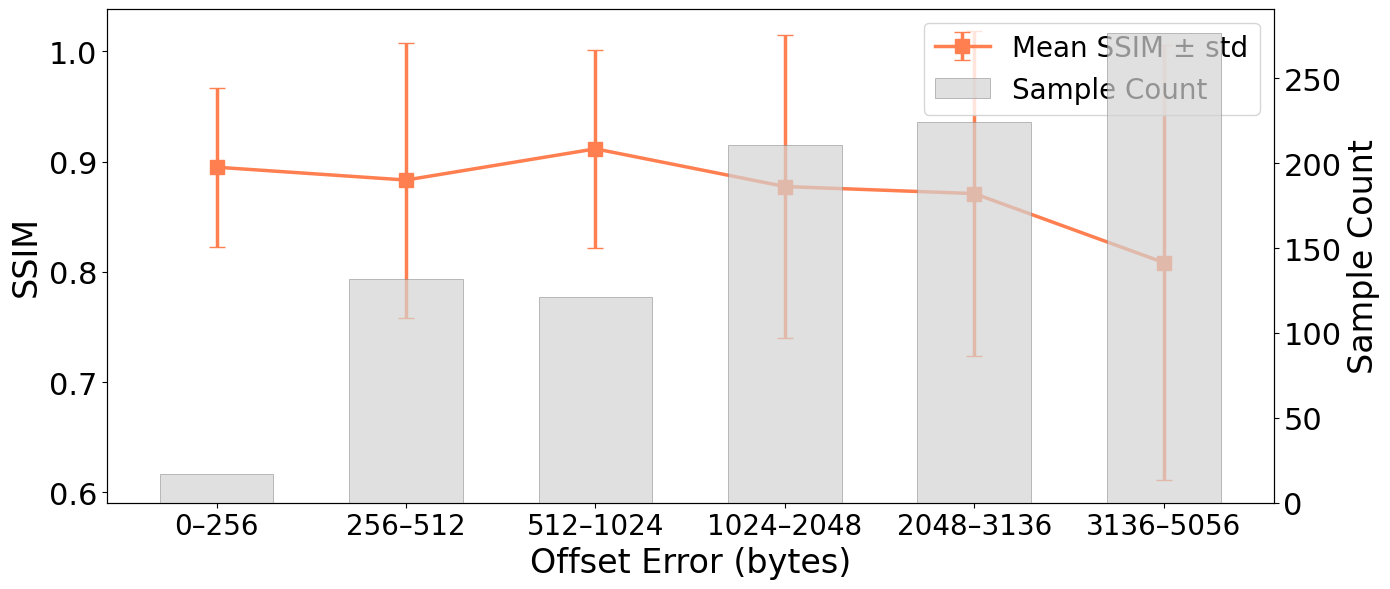

Saved: misalignment_sensitivity.pdf/png


In [8]:
# ── Misalignment Sensitivity: 그래프 (계산 셀 먼저 실행) ─────────────────────
import re, os, ast, torch, numpy as np, matplotlib.pyplot as plt
from collections import OrderedDict as _OD
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

# ── Parse actual offset errors from collect_log.txt ──────────────────────────
_gt_offsets, _pred_offsets, _sample_ids = [], [], []

with open('
    for _i, _line in enumerate(_f, 1):
        _m = re.search(r'label=(\d+)\s+image_gpa=0x[0-9a-f]+\s+offset=(\d+)', _line)
        if _m:
            _gt_offsets.append((_i, int(_m.group(2)), int(_m.group(1))))
        _m = re.search(r'^Offset:\s+(\d+)\s+match rate:\s+([\d.]+)%', _line)
        if _m:
            _pred_offsets.append((_i, int(_m.group(1)), float(_m.group(2))))
        _m = re.match(r'^label=(\d+)\s+index=(\d+)\s*$', _line)
        if _m:
            _sample_ids.append((_i, int(_m.group(1)), int(_m.group(2))))

_first_gt_line = _gt_offsets[0][0]
_pairs, _gi = [], 0
for _pl, _po, _mr in _pred_offsets:
    if _pl < _first_gt_line:
        continue
    while _gi < len(_gt_offsets) - 1 and _gt_offsets[_gi + 1][0] < _pl:
        _gi += 1
    _gl, _go, _ = _gt_offsets[_gi]
    if _gl < _pl:
        _sids = [(l, idx) for ln, l, idx in _sample_ids if _gl < ln < _pl]
        if _sids:
            _pairs.append((_sids[0][1], _go, _po))

_deduped = _OD()
for _idx, _gt, _pred in _pairs:
    _deduped[_idx] = (_gt, _pred)

# ── 실제 misaligned 샘플의 SSIM 계산 ─────────────────────────────────────────
OUT_DIR = '
_all_list_files = {int(m.group(2)): f
    for f in os.listdir(OUT_DIR) if f.endswith('.out_v5.list')
    for m in [re.match(r'^(\d+)-(\d+)\.out_v5\.list$', f)] if m}

misaligned = []
for idx, (gt_off, pred_off) in _deduped.items():
    err = abs(pred_off - gt_off)
    if err == 0 or idx not in _all_list_files or idx >= len(mnist_img):
        continue
    with open(os.path.join(OUT_DIR, _all_list_files[idx])) as fh:
        sp = ast.literal_eval(fh.read().strip())
    if len(sp) != 196:
        continue
    sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = dec(encoder(sp_t)).squeeze().cpu().numpy()
    misaligned.append((idx, err, compute_ssim(mnist_img[idx], recon)))

print(f'Misaligned samples: {len(misaligned)}')

# ── 구간별 집계 ──────────────────────────────────────────────────────────────
bins = [(0, 256), (256, 512), (512, 1024), (1024, 2048), (2048, 3136), (3136, 5056)]
bin_means, bin_stds, bin_counts, bin_labels = [], [], [], []
for lo, hi in bins:
    sel = [s for _, e, s in misaligned if lo < e <= hi]
    if sel:
        arr = np.array(sel)
        bin_means.append(arr.mean())
        bin_stds.append(arr.std())
        bin_counts.append(len(sel))
        bin_labels.append(f'{lo}–{hi}')

# ── Plot ──────────────────────────────────────────────────────────────────────
FS = 24
x_pos = np.arange(len(bin_labels))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax2.bar(x_pos, bin_counts, width=0.6, color='lightgray', edgecolor='gray',
        linewidth=0.5, alpha=0.7, zorder=2, label='Sample Count')
ax2.set_ylabel('Sample Count', fontsize=FS)
ax2.tick_params(axis='y', labelsize=FS-2)

ax1.errorbar(x_pos, bin_means, yerr=bin_stds, fmt='s-', color='coral',
             linewidth=2.5, markersize=10, capsize=6, label='Mean SSIM ± std',
             zorder=4)

ax1.set_xlabel('Offset Error (bytes)', fontsize=FS)
ax1.set_ylabel('SSIM', fontsize=FS)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(bin_labels, fontsize=FS-4)
ax1.tick_params(axis='y', labelsize=FS-2)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=FS-4, loc='upper right')

plt.tight_layout()
fig.savefig('misalignment_sensitivity.pdf', bbox_inches='tight')
fig.savefig('misalignment_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: misalignment_sensitivity.pdf/png')

In [6]:
# ── 실제 오프셋 에러가 있는 샘플의 SSIM ──────────────────────────────────────
# 계산 셀(ms_results)과 그래프 셀(_deduped) 먼저 실행
import torch, numpy as np, os, ast, re
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

OUT_DIR = '

misaligned = []
for idx, (gt_off, pred_off) in _deduped.items():
    err = abs(pred_off - gt_off)
    if err == 0:
        continue
    fname = None
    for f in os.listdir(OUT_DIR):
        if f.endswith('.out_v5.list'):
            m = re.match(r'^(\d+)-(\d+)\.out_v5\.list$', f)
            if m and int(m.group(2)) == idx:
                fname = f
                break
    if fname is None or idx >= len(mnist_img):
        continue
    with open(os.path.join(OUT_DIR, fname)) as fh:
        sp = ast.literal_eval(fh.read().strip())
    if len(sp) != 196:
        continue
    sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = dec(encoder(sp_t)).squeeze().cpu().numpy()
    ssim = compute_ssim(mnist_img[idx], recon)
    misaligned.append((idx, err, ssim))

misaligned.sort(key=lambda x: x[1])
ssims = np.array([s for _, _, s in misaligned])

print(f'오프셋 에러 != 0 인 샘플: {len(misaligned)} / {len(_deduped)}')
print(f'Mean SSIM: {ssims.mean():.4f}')
print(f'Median SSIM: {np.median(ssims):.4f}')
print(f'Min SSIM: {ssims.min():.4f}, Max SSIM: {ssims.max():.4f}')
print()

print(f'에러 구간별 SSIM:')
bins = [(0, 256), (256, 512), (512, 1024), (1024, 2048), (2048, 3136), (3136, 5000)]
for lo, hi in bins:
    sel = [s for _, e, s in misaligned if lo < e <= hi]
    if sel:
        arr = np.array(sel)
        print(f'  {lo:>4}–{hi:>4}B: n={len(sel):>4}  '
              f'mean={arr.mean():.4f}  median={np.median(arr):.4f}  '
              f'min={arr.min():.4f}  max={arr.max():.4f}')

오프셋 에러 != 0 인 샘플: 982 / 2501
Mean SSIM: 0.8617
Median SSIM: 0.9287
Min SSIM: 0.2464, Max SSIM: 0.9878

에러 구간별 SSIM:
     0– 256B: n=  17  mean=0.8948  median=0.9240  min=0.6776  max=0.9605
   256– 512B: n= 132  mean=0.8832  median=0.9302  min=0.3960  max=0.9818
   512–1024B: n= 121  mean=0.9115  median=0.9406  min=0.3790  max=0.9781
  1024–2048B: n= 211  mean=0.8773  median=0.9319  min=0.3075  max=0.9813
  2048–3136B: n= 224  mean=0.8709  median=0.9338  min=0.2551  max=0.9810
  3136–5000B: n= 277  mean=0.8084  median=0.9124  min=0.2464  max=0.9878


In [4]:
# ── 4개 모델 요약 테이블 (v6r / v8r2 / v9r / v10) ────────────────────────────
# 선행: 3-model 비교 추론 셀(b5fe9012) 먼저 실행 → v8r2_ssim / v9r_ssim / v10_ssim
#       (v6r는 이 셀에서 retrieval 추론을 직접 수행)
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from scipy.ndimage import uniform_filter

def compute_ssim(a, b, win=7, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    a, b = a.astype(np.float64), b.astype(np.float64)
    mu1, mu2 = uniform_filter(a, win), uniform_filter(b, win)
    s1  = uniform_filter(a*a, win) - mu1**2
    s2  = uniform_filter(b*b, win) - mu2**2
    s12 = uniform_filter(a*b, win) - mu1*mu2
    return float(((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean())

# ── v6r retrieval 추론 (Mean SSIM 계산용) ───────────────────────────────────
class _V6Enc(nn.Module):
    def __init__(self, input_dim=196, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Linear(256, embed_dim),
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

_v6enc = _V6Enc().to(device)
_v6enc.load_state_dict(torch.load('./sparsity_encoder_v6r_new.pth', map_location=device))
_v6enc.eval()
_emb_db = np.load('./v6r_embeddings_new.npy')
_img_db = np.load('./v6r_images_new.npy')

v6r_ssim = []
with torch.no_grad():
    for sp, lbl, idx in test_items:            # test_items: b5fe9012 셀에서 생성
        sp_t = torch.tensor(sp, dtype=torch.float32).unsqueeze(0).to(device)
        q    = _v6enc(sp_t).cpu().numpy()
        ret  = int(np.argmax(_emb_db @ q.T))
        v6r_ssim.append(compute_ssim(mnist_img[idx], _img_db[ret]))
v6r_ssim = np.array(v6r_ssim)

# ── 모델 사이즈 & 메타데이터 사이즈 ─────────────────────────────────────────
# Model Size : 모델 파라미터(.pth)만. v10은 encoder + decoder.
# Metadata   : 들고 있어야 하는 MNIST 데이터셋(image DB + embedding DB).
#              retrieval(v6r)만 원본 데이터셋을 저장해야 하고, 생성 모델은 필요 없음(—).
def _sz(*paths):
    return sum(os.path.getsize(p) for p in paths)

MB = 1024 * 1024

rows = [
    ('Retrieval (v6r)',
        _sz('./sparsity_encoder_v6r_new.pth'),
        _sz('./v6r_images_new.npy', './v6r_embeddings_new.npy'),
        v6r_ssim),
    ('UNet+PatchGAN CC (v8r2)',
        _sz('./unet_gan_generator_v8r2_new.pth'),
        0,  v8r2_ssim),
    ('UNet+PatchGAN (v9r)',
        _sz('./unet_gan_generator_v9r_new.pth'),
        0,  v9r_ssim),
    ('Encoder-Decoder (v10)',
        _sz('./sparsity_encoder_v6r_new.pth', './v10_decoder_new.pth'),
        0,  v10_ssim),
]

def _fmt_meta(b):
    return '—' if b == 0 else f'{b/MB:.1f}MB'

# ── 출력 ─────────────────────────────────────────────────────────────────────
hdr = f'{"Model":<26}  {"Model Size":>12}  {"Metadata":>10}  {"Mean SSIM":>10}  {"SSIM<0.8":>9}'
print(hdr)
print('-' * len(hdr))
for name, msize, meta, sarr in rows:
    lt08 = (sarr < 0.8).mean() * 100
    print(f'{name:<26}  {msize/MB:>10.2f}MB  {_fmt_meta(meta):>10}  '
          f'{sarr.mean():>10.4f}  {lt08:>8.2f}%')

# ── LaTeX 표 ─────────────────────────────────────────────────────────────────
print('\n% ── LaTeX ──')
print(r'\begin{tabular}{lrrrr}')
print(r'\toprule')
print(r'Model & Model Size & Metadata & Mean SSIM & SSIM$<$0.8 (\%) \\')
print(r'\midrule')
for name, msize, meta, sarr in rows:
    lt08 = (sarr < 0.8).mean() * 100
    meta_s = '--' if meta == 0 else f'{meta/MB:.1f}\\,MB'
    print(f'{name} & {msize/MB:.2f}\\,MB & {meta_s} & '
          f'{sarr.mean():.4f} & {lt08:.2f} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')

Model                         Model Size    Metadata   Mean SSIM   SSIM<0.8
---------------------------------------------------------------------------
Retrieval (v6r)                   1.03MB     208.7MB      0.9776      3.64%
UNet+PatchGAN CC (v8r2)           3.94MB           —      0.9337      6.36%
UNet+PatchGAN (v9r)               1.81MB           —      0.6817     39.34%
Encoder-Decoder (v10)             8.48MB           —      0.9067     13.07%

% ── LaTeX ──
\begin{tabular}{lrrrr}
\toprule
Model & Model Size & Metadata & Mean SSIM & SSIM$<$0.8 (\%) \\
\midrule
Retrieval (v6r) & 1.03\,MB & 208.7\,MB & 0.9776 & 3.64 \\
UNet+PatchGAN CC (v8r2) & 3.94\,MB & -- & 0.9337 & 6.36 \\
UNet+PatchGAN (v9r) & 1.81\,MB & -- & 0.6817 & 39.34 \\
Encoder-Decoder (v10) & 8.48\,MB & -- & 0.9067 & 13.07 \\
\bottomrule
\end{tabular}
